In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper


In [3]:
# ignore warnings

import warnings
warnings.filterwarnings('ignore')


In [4]:
sigma_SB = 5.670374419e-8  # Stefan-Boltzmann constant (W/m²/K⁴)
big_G = 6.67430e-11  # Gravitational constant (m³/kg/s²)
M_Earth = 5.972e24  # Mass of Earth (kg)
R_Earth = 6371e3  # Radius of Earth (m)

## attempt to compute required heat fluxes for different ice layer thicknesses

In [5]:
## use the expressions in the Abbott paper ( https://iopscience.iop.org/article/10.1088/2041-8205/735/2/L27/meta ) to compute the required heat flux for a given ice layer thickness 

# (1) H_cond = ( A / F ) * np.log( T_H / T_0 )
# H_cond is height of ice shell
# T_H is temp at ice-water interface, melting temp of water == 260 K from paper (or 176 for ammonia-water mixture)
# T_0 is temp at surface == 220 K from the paper
# A is a constant == 100 W/m
# F is geothermal heat flux through the surface of the crust

# re-cast in terms of F to get the required heat flux for a given ice shell thickness
#def required_heat_flux_cond(H_cond, T_H=260, T_0=220, A=651):
#    return (A/H_cond) * np.log(T_H / T_0)

# (2) H_conv ** ( 1 - 3 * beta ) = ( a * k * ( T_H - T_c ) ) / F * ( ( g * alpha * rho * ( T_H - T_c ) ) / ( kappa * eta * T_avg ) )**beta

# convection within the ice layer capped by stagnant ice lid - convection occurs below T_c, where T_c is computed according to (Kirk and Stevenson, 1987)
# eta(T) = eta_0 * exp( l * ( T_m / T - 1 ) )
# T_m == T_H, 
# l==25 is a constant, ( 18 - 35 ) suggested by Hunten et al. (1984)
# eta_0 is 10**13 melting point viscoscity of ice,

# use this to compute T_c for the ice layer
#def viscosity(T, T_H=273, eta_0=10**13, l=25):
#    return eta_0 * np.exp( l * ( T_H / T - 1 ) )

# --> then use T_c to compute the required heat flux for a given ice shell thickness

# a Nusselt-Rayleigh scaling (Nu = a * Ra ** beta) yields the thickness of the convecting region between T_c and T_H

# T_avg = ( T_H + T_c ) / 2
# kappa = 1.47e-6 m^2/s thermal diffusivity of ice
# alpha = 1.56e-4 1/K thermal expansivity of ice
# rho = 917 kg/m^3 density of ice 
# k = 3.3 W/m/K thermal conductivity of ice
# a = 0.12
# beta = 0.3
# g = GM_p / R_p^2 = 9.81 m/s^2 gravitaional acceleration at the surface of the planet... depends on mass and radius of the planet, but for now, just use Earth values

# re-cast in terms of F to get the required heat flux for a given ice shell thickness
#def required_heat_flux_conv(H_conv, T_H=273, T_c=None, T_avg=None, kappa=1.47e-6, alpha=1.56e-4, rho=917, k=3.3, a=0.12, beta=0.3, eta=10**13, g=9.81):
#    if T_c is None:
#        T_c = T_H  # default value if not provided
#    if T_avg is None:
#        T_avg = (T_H + T_c) / 2
#    return ( a * k * ( T_H - T_c ) ) / H_conv ** ( 1 - 3 * beta ) * ( ( g * alpha * rho * ( T_H - T_c ) ) / ( kappa * eta * T_avg ) )**beta

# (3) H_lid  = ( A / F ) * np.log( T_c / T_0 )
# if H_lid + H_conv > H_cond, then the ice layer thickness is H_lid -- this corresponds to critical rayleigh number of 1000 within convecting layer

# re-cast in terms of F to get the required heat flux for a given ice shell thickness
#def required_heat_flux_lid(H_lid, T_c, T_0=1, A=651):
#    return (A/H_lid) * np.log(T_c / T_0)

# start with the phase diagram of ice

Text(0, 0.5, 'Pressure (MPa)')

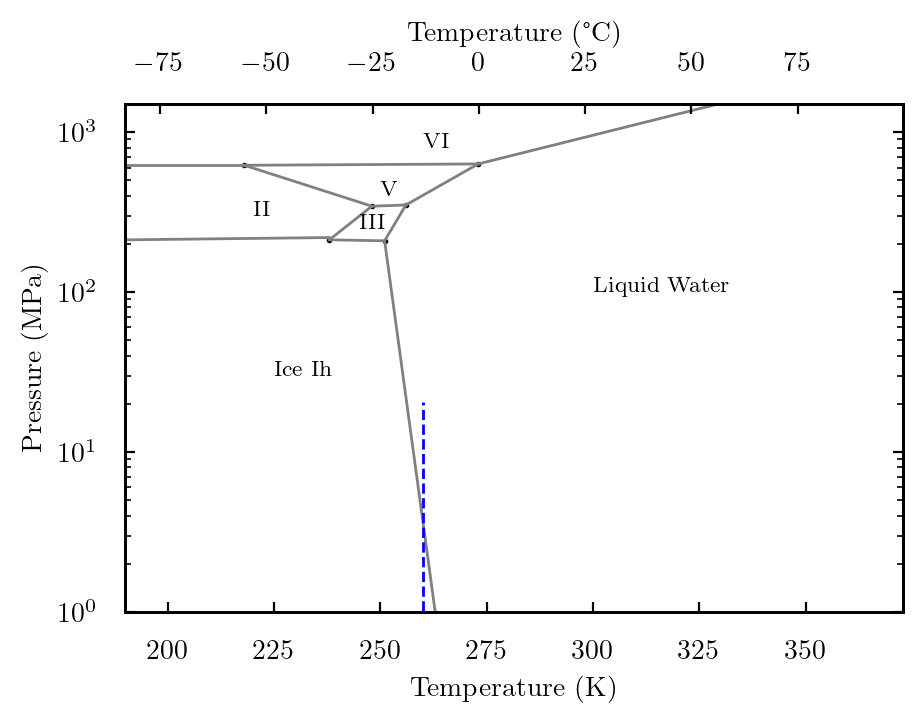

In [6]:
## pressure - temperature diagram for ice and water
## is rather complex and difficult to plot

# here is a list of transition points:
# temperature ranges between ~ 170 K and 355 K, and pressures between 0.01 MPa and 2216 MPa
# liquid water - vapor - ice Ih: .611 kPa, 273.15 K
# critical point: 22.064 MPa, 647.096 K
# boiling point at 1 atm: 0.101325 MPa, 373.15 K

# liquid water - ice Ih    : 0.01 MPa, 273.15 K
# ice Ih - ice III - liquid: 209 MPa, 251 K
# ice Ih - ice II - ice III: 212 MPa, 238 K
# ice II - ice III - ice V : 344 MPa, 248 K
# ice III - ice V - liquid : 350 MPa, 256 K
# ice V - ice VI - liquid  : 632 MPa, 273 K
# ice V - ice VI - ice II  : 620 MPa, 218 K
# ice VI - ice VII - liquid: 2216 MPa, 355 K
# ice VI - ice VII - ice VIII: 2100 MPa, 278 K

# can we connect some dots and draw a rough phase diagram? yes, but it will be approximate and not fully accurate
fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.5), dpi=200, constrained_layout=True)
# plot the phase transition points
ax.scatter([273.15, 251, 238, 248, 256, 273, 218, 355, 278],
           [0.01, 209, 212, 344, 350, 632, 620, 2216, 2100],
           color='black', s=1)
# connect the dots with lines to approximate the phase boundaries
ax.plot([273.15, 251, 238], [0.01, 209, 212], color='gray', lw=1, label='Ice Ih - Ice II - Ice III')
ax.plot([238, 248, 256], [212, 344, 350], color='gray', lw=1, label='Ice II - Ice III - Ice V')
ax.plot([256, 273], [350, 632], color='gray', lw=1, label='Ice V - Ice VI - Liquid')
ax.plot([170, 278], [1890, 2100], color='gray', lw=1, label='Ice VI - Ice VII - Ice VIII')
ax.plot([273, 355], [632, 2216], color='gray', lw=1, label='Liquid Water - Ice VII - Critical Point')
ax.plot([251, 256], [209, 350], color='gray', lw=1, label='Ice III - Ice V - Liquid')
ax.plot([278, 355], [2100, 2216], color='gray', lw=1, label='Ice VII - Liquid Water - Critical Point')
ax.plot([248, 218], [344, 620], color='gray', lw=1, label='Ice II - Ice V - Ice VI')
ax.plot([218, 273], [620, 632], color='gray', lw=1, label='Ice VI - Ice V - Liquid')
ax.plot([238, 170], [219, 209], color='gray', lw=1, label='Ice Ih - Ice II - Ice III')
ax.plot([218, 170], [620, 620], color='gray', lw=1, label='Ice Ih - Ice II - Ice III')
ax.plot([355, 373], [2216, 2280], color='gray', lw=1, label='Liquid Water - Critical Point - Boiling Point')

# add text labels for the different phases
ax.text(225, 30, 'Ice Ih', fontsize=8)
ax.text(220, 300, 'II', fontsize=8)
ax.text(245, 250, 'III', fontsize=8)
ax.text(250, 400, 'V', fontsize=8)
ax.text(260, 800, 'VI', fontsize=8)
ax.text(300, 100, 'Liquid Water', fontsize=8)
ax.set_xlim(190, 373)
ax.set_ylim(1, 1500)

# make a second x axis on the top for degrees C
ax2 = ax.twiny()
ax2.set_xlabel('Temperature (°C)')
ax2.set_xlim(ax.get_xlim()[0] - 273.15, ax.get_xlim()[1] - 273.15)

# add a vertical line at 260 K, which is the melting point of water under pressures less than 620 MPa 
# that stops at 620 MPa, which is the pressure at which ice V melts into liquid water
ax.axvline(x=260, ymin=1/1500, ymax=620/1500, color='blue', lw=1, ls='--', label='Melting Point of Water (260 K)')

# set log scale for pressure
ax.set_yscale('log')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (MPa)')
#ax.set_title('Approximate Phase Diagram of Water and Ice', fontsize=10)

# Compute the height of an ice layer for a given heat flux
our heat fluxes change with time, scale _slightly_ differently with planet mass, and radiogenic concentrations also change the heat flux.

In [7]:
# compute the conductive case
# for a given T_H and heat flux F, compute the ice layer thickness H_cond

def H_cond(T_H=260, F=0.087, A=651, T_0=False):

    # compute the surface temperature using stefan-boltzmann law if not provided
    if not T_0:
        T_0 = (F / sigma_SB) ** 0.25

    if T_0==220:
        # there will be an extra layer of CO2 ice on top of the water ice layer, which will have a different melting point and thermal conductivity, so we need to account for that in the calculation of the ice layer thickness
        H_cond = (A / F) * np.log(T_H / T_0)
        #print("H_cond: CO2 ice layer present, adjusting calculations accordingly.")
        A_CO2=100
        H_CO2 = (A_CO2 / F) * np.log(T_0 / 195)  # CO2 ice layer thickness, 195 is sublimation temperature of CO2 ice in K
        return H_cond + H_CO2

    # if T_H <= T_0, then ice layer thickness is zero
    if T_H <= T_0:
        return 0.0
    
    # compute the ice layer thickness using the conductive heat transfer formula
    H_cond = (A / F) * np.log(T_H / T_0)

    return H_cond

In [8]:
# test it.
# A = 651 for ice. if a CO2 layer is tested, T_0=220 and A=100.
test_H_cond = H_cond(T_H=260, F=0.087, A=651, T_0=False)
test_H_cond

np.float64(14963.923584201222)

In [9]:
# compute convective case
# for a given T_H and heat flux F, compute the ice layer thickness H_conv

def viscosity(T, T_H=260, eta_0=1e13, l=25):
    return eta_0 * np.exp(l * ((T_H / T) - 1))

def H_conv(T_H=260, F=0.087, A=651, g=9.81, l=25, T_0=False):

    # compute surface temperature using stefan-boltzmann law if not provided
    if not T_0:
        T_0 = (F / sigma_SB) ** 0.25
        #print(f"Surface temperature = {T_0:.2f} K")
        
    # if T_H <= T_0, then ice layer thickness is zero
    if T_H <= T_0:
        return 0.0
    
    # compute the critical temperature T_c, 
    # assuming that viscosity is reduced by a factor of 10 across convecting region,
    # we can solve for T_c using the viscosity formula and the assumption that eta(T_c) = eta(T_H) / 10
    gamma = 10
    T_c = T_H / (1 + (1/l) * np.log(gamma))
    #print(T_c)

    if T_c <= T_0:
        raise ValueError("Critical temperature T_c must be greater than T_0 for convection to occur.")
    if T_c >= T_H:
        return str('no convection')

    # compute T_avg within convective region
    T_avg = (T_H + T_c) / 2
    delta_T = T_H - T_c

    # compute avg viscosity within convective region
    eta_avg = viscosity(T_avg, T_H=T_H, l=l)
    
    # compute thickness of convecting region using Nusselt-Rayleigh scaling
    kappa = 1.47e-6  # m^2/s thermal diffusivity of ice
    alpha = 1.56e-4  # 1/K thermal expansivity of ice
    rho = 917  # kg/m^3 density of ice
    k = 3.3  # W/m/K thermal conductivity of ice
    a = 0.12  # dimensionless constant from Nusselt-Rayleigh scaling
    beta = 0.3  # dimensionless constant from Nusselt-Rayleigh scaling
    
    # follows Nu = aRa^beta, where Ra is the Rayleigh number
    H_conv = ( ( a * k * (delta_T) / F ) * 
              ( ( g * alpha * rho * (delta_T) / ( kappa * eta_avg ) ) ** beta ) ) ** (1 / (1 - 3 * beta))

    #Ra = (g * alpha * rho * (delta_T) * (H_conv ** 3)) / (kappa * eta_avg)

    # compute thickness of conductive lid atop convecting region
    H_lid = (A / F) * np.log(T_c / T_0)

    if T_0 == 220:
        # there will be an extra layer of CO2 ice on top of the water ice layer, which will have a different melting point and thermal conductivity, so we need to account for that in the calculation of the ice layer thickness
        A_CO2=100
        #print("H_conv: CO2 ice layer present, adjusting calculations accordingly.")
        H_CO2 = (A_CO2 / F) * np.log(T_0 / 195)  # CO2 ice layer thickness, 195 is sublimation temperature of CO2 ice in K
        return H_conv + H_lid + H_CO2
    #print(H_conv, H_lid)
    
    return H_conv + H_lid

In [10]:
# for a given heat T_H and heat flux F, compare the thicknesses of the ice layers for conduction and convection
test_flux = 0.0300 # approximate scaled flux for 0.1 earth masses - should be about 100 km of ice layer thickness

test_H_cond = H_cond(T_H=260, F=test_flux, A=651, T_0=False)
test_H_conv = H_conv(T_H=260, F=test_flux, A=651, g=big_G * 0.1 * M_Earth / (R_Earth)**2, T_0=False)

if test_H_conv > test_H_cond:
    print(f"Convection dominates: H = {test_H_conv/1e3:.2f} km")
else:
    print(f"Conduction dominates: H = {test_H_cond/1e3:.2f} km")

Conduction dominates: H = 49.17 km


# take the heat fluxes from the files in the mass_sweep directory, and use them as input to the ice layer thickness calculations.

In [11]:
## and now read the files in the mass_sweep_radiogenic directory. 
radiogenic_mass_sweep_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep_radiogenic/'
list_files = !ls {radiogenic_mass_sweep_dir}*heat_flux*.dat

masses = []
concentrations = []
times = []
conv_heat_fluxes = []; mag_heat_fluxes = []; surf_heat_fluxes = []; total_surf_heat_fluxes = []

for file in list_files:
    mass = float(file.split('_')[-3].split('m')[0])
    concentration = float(file.split('_')[-2])
    masses.append(mass)
    concentrations.append(concentration)
    # read the files
    time, conv_heat_flux, mag_heat_flux, surf_heat_flux = np.genfromtxt(file, unpack=True)
    # append data to lists
    times.append(time)
    conv_heat_fluxes.append(conv_heat_flux)
    mag_heat_fluxes.append(mag_heat_flux)
    surf_heat_fluxes.append(surf_heat_flux)
    total_surf_heat_fluxes.append(surf_heat_flux + mag_heat_flux)

#times = np.array(times); conv_heat_fluxes = np.array(conv_heat_fluxes); mag_heat_fluxes = np.array(mag_heat_fluxes); surf_heat_fluxes = np.array(surf_heat_fluxes)
masses = np.array(masses); concentrations = np.array(concentrations)
unique_masses = np.unique(masses); unique_concentrations = np.unique(concentrations)

#print(f"Unique masses: {unique_masses}")
#print(f"Unique concentrations: {unique_concentrations}")

In [12]:
mass_1_conc_1 = []
mass_1_conc_1_times = []
mass_1_conc_1_tot_surf_heat_flux = []

# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if mass != 1.0:
        continue

    if concentration == 1.0:
        mass_1_conc_1_times.append(time)
        #print(mass, concentration)
        #print(total_surf_heat_flux)
        mass_1_conc_1_tot_surf_heat_flux.append(total_surf_heat_flux)

#mass_1_conc_1 = np.array(mass_1_conc_1[0])
mass_1_conc_1_times = np.array(mass_1_conc_1_times[0])
mass_1_conc_1_tot_surf_heat_flux = np.array(mass_1_conc_1_tot_surf_heat_flux[0])

#print(mass_1_conc_1)
print(len(mass_1_conc_1_tot_surf_heat_flux))
print(len(mass_1_conc_1_times))

1884
1884


In [13]:
# for a given heat T_H and heat flux F, compare the thicknesses of the ice layers for conduction and convection
ice_heights_mass_1_conc_1 = []
transport_regime_mass_1_conc_1 = []
for heat_flux in mass_1_conc_1_tot_surf_heat_flux:
    grav = big_G * 1.0 * M_Earth / (R_Earth)**2  # assuming Earth-like mass and radius
    #print(grav)
    #print(heat_flux)
    test_H_cond = H_cond(T_H=260, F=heat_flux, A=651, T_0=False)
    test_H_conv = H_conv(T_H=260, F=heat_flux, A=651, g=grav, T_0=False)

    if test_H_conv > test_H_cond:
        #print(f"Convection dominates: H = {test_H_conv:.2f} m")
        ice_heights_mass_1_conc_1.append(test_H_conv)
        transport_regime_mass_1_conc_1.append('convection')
    else:
        #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
        ice_heights_mass_1_conc_1.append(test_H_cond)
        transport_regime_mass_1_conc_1.append('conduction')

ice_heights_mass_1_conc_1 = np.array(ice_heights_mass_1_conc_1)

Text(0.5, 1.0, 'Ice Layer Thickness for 1 M$_\\oplus$ Planet with [X/Fe] = 0.0')

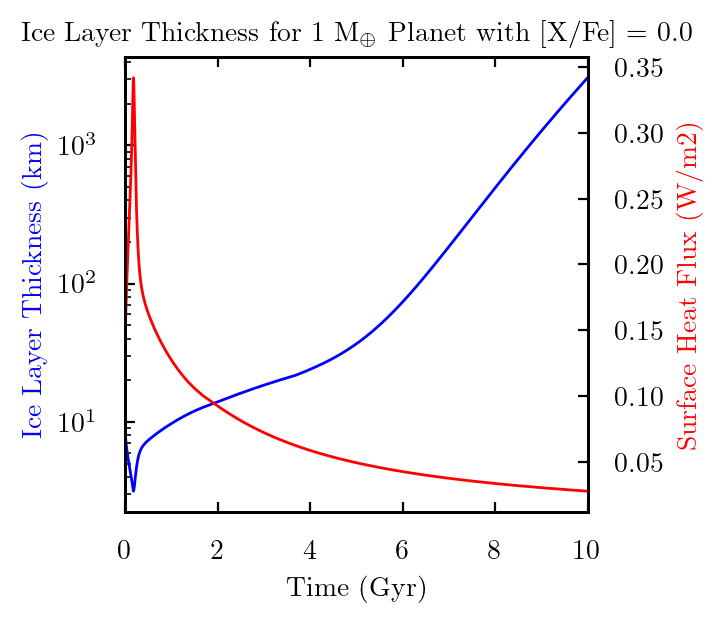

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3), dpi=200, constrained_layout=True)

ax.plot(mass_1_conc_1_times, ice_heights_mass_1_conc_1 / 1e3, alpha=1.0, lw=1.0, c='blue')

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Ice Layer Thickness (km)', color='blue')
ax.set_yscale('log')
ax.set_xlim(np.min(mass_1_conc_1_times), np.max(mass_1_conc_1_times))

ax2 = ax.twinx()
ax2.set_ylabel('Surface Heat Flux (W/m2)', color='red')
ax2.plot(mass_1_conc_1_times, mass_1_conc_1_tot_surf_heat_flux, alpha=1.0, lw=1.0, c='red')

ax.set_title('Ice Layer Thickness for 1 M$_\oplus$ Planet with [X/Fe] = 0.0', fontsize=10)

In [15]:
conc_1_times = []
conc_1_masses = []
conc_1_tot_surf_heat_flux = []

# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if concentration == 1.0:
        conc_1_times.append(time)
        conc_1_masses.append(mass)
        #print(mass, concentration)
        #print(total_surf_heat_flux)
        conc_1_tot_surf_heat_flux.append(total_surf_heat_flux)

#conc_1_times = np.array(conc_1_times)
conc_1_masses = np.array(conc_1_masses)
#conc_1_tot_surf_heat_flux = np.array(conc_1_tot_surf_heat_flux)

#print(len(conc_1_tot_surf_heat_flux))
#print(len(conc_1_times))

conc_1_fluxes_at_time = []
for time, flux in zip(conc_1_times, conc_1_tot_surf_heat_flux):
    for t, f in zip(time, flux):
        if np.isclose(t, 4.5, atol=0.0084):
            #print(f"At time {t:.2f} Gyr, the surface heat flux is {f:.4f} W/m².")
            conc_1_fluxes_at_time.append(f)

#print(len(conc_1_masses))
#print(len(conc_1_fluxes_at_time))

In [16]:
# compute the ice height for the conc_1_fluxes_at_time
ice_heights_conc_1 = []
for mass, heat_flux in zip(conc_1_masses, conc_1_fluxes_at_time):
    # scale radius of the planet following Brad's models
    R_planet = R_Earth * mass**0.27
    # compute the communsurate surface gravity for the planet
    grav = big_G * mass * M_Earth / (R_planet)**2 
    test_H_cond = H_cond(T_H=260, F=heat_flux, A=651, T_0=False)
    test_H_conv = H_conv(T_H=260, F=heat_flux, A=651, g=grav, T_0=False)

    if test_H_conv > test_H_cond:
        ice_heights_conc_1.append(test_H_conv)
    else:
        ice_heights_conc_1.append(test_H_cond)
        
ice_heights_conc_1 = np.array(ice_heights_conc_1)

In [17]:
# compute scaled mean ocean depths using a mass-scaling relation.
D_star = 4000 # mean depth of Earth's oceans in meters

def ocean_scaling_relation(planet_mass):
    depth = D_star * (planet_mass ** (1 - 2*0.27))  # using the scaling relation from the paper
    return depth

In [18]:
# compute scaled heat fluxes for a given mass and concentration at 4.5 Gyr
# abbot + switzer use the same mass scaling relation for the heat fluxes.
F_star = 0.087

def heat_flux_scaling_relation(planet_mass):
    flux = F_star * (planet_mass ** (1 - 2*0.27))  # using the scaling relation from the paper
    return flux

In [19]:
# now compute the heat fluxes for a range of planet masses at 4.5 Gyr, using the mass-scaling relation for the heat fluxes
planet_masses_test = np.arange(0.01, 10, 0.01)  # example planet masses in Earth masses
heat_fluxes_test = [heat_flux_scaling_relation(mass) for mass in planet_masses_test]
heat_fluxes_test = np.array(heat_fluxes_test)

(0.02, 0.1)

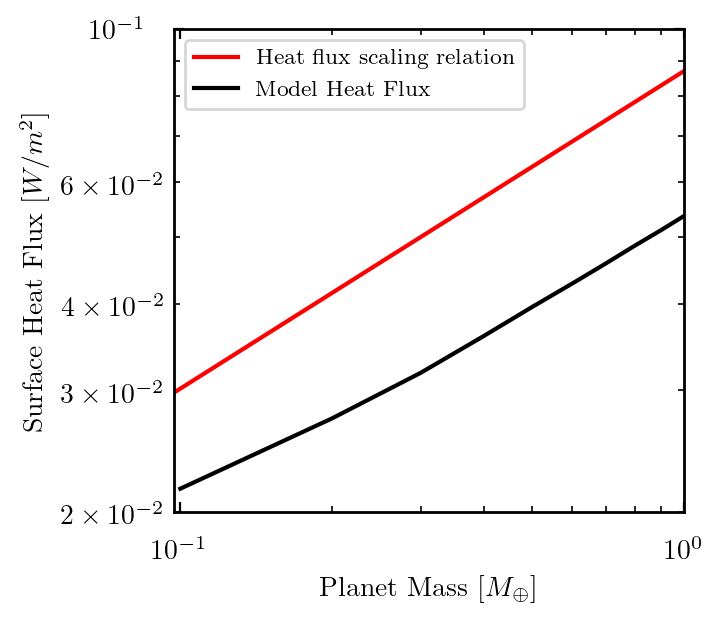

In [20]:
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.plot(planet_masses_test, heat_fluxes_test, c='red', label='Heat flux scaling relation')
ax.plot(conc_1_masses, conc_1_fluxes_at_time, c='black', label='Model Heat Flux')
ax.set_xlabel(r'Planet Mass [$M_{\oplus}$]')
ax.set_ylabel(r'Surface Heat Flux [$W/m^2$]')
ax.legend(loc='upper left', fontsize=8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.097, 1.0)
ax.set_ylim(2e-2, 1e-1)

In [21]:
# now compute the ice heights for a range of planet masses at 4.5 Gyr, using the mass-scaling relation for the heat fluxes
ice_heights_test = []
for mass in planet_masses_test:
    # compute heat flux from the mass-scaling relation
    F = heat_flux_scaling_relation(mass)
    # scale radius of the planet to the mass, following Brad's models
    R_planet = R_Earth * mass**0.27
    # compute the surface gravity for the planet
    grav = big_G * mass * M_Earth / (R_planet)**2 
    # compute the ice heights for conduction and convection
    test_H_cond = H_cond(T_H=260, F=F, A=651, T_0=False)
    test_H_conv = H_conv(T_H=260, F=F, A=651, g=grav, T_0=False)
    # compare the ice heights and append the larger one to the list
    if test_H_conv > test_H_cond:
        ice_heights_test.append(test_H_conv)
    else:
        ice_heights_test.append(test_H_cond)

ice_heights_test = np.array(ice_heights_test)

# now compute the ice heights for a range of planet masses at 4.5 Gyr, using the mass-scaling relation for the heat fluxes
ice_heights_test_CO2 = []
for mass, heat_flux in zip(planet_masses_test, heat_fluxes_test):
    # scale radius of the planet following Brad's models
    R_planet = R_Earth * mass**0.27
    # compute the communsurate surface gravity for the planet
    grav = big_G * mass * M_Earth / (R_planet)**2 
    # compute the ice heights for conduction and convection
    test_H_cond = H_cond(T_H=220, F=heat_flux, A=651, T_0=False)
    test_H_conv = H_conv(T_H=220, F=heat_flux, A=651, g=grav, T_0=False)
    # compare the ice heights and append the larger one to the list
    if test_H_conv > test_H_cond:
        ice_heights_test_CO2.append(test_H_conv)
    else:
        ice_heights_test_CO2.append(test_H_cond)

ice_heights_test_CO2 = np.array(ice_heights_test_CO2)

In [22]:
ice_heights_test = np.array(ice_heights_test)
ice_heights_test_CO2 = np.array(ice_heights_test_CO2)

In [23]:
ocean_depths_with_mass = ocean_scaling_relation(planet_masses_test)
ocean_depths_with_mass_01 = ocean_depths_with_mass * 0.1
ocean_depths_with_mass_10 = ocean_depths_with_mass * 10
ocean_depths_with_mass_100 = ocean_depths_with_mass * 100
#print(len(ocean_depths_with_mass), len(ice_heights_test), len(ice_heights_test_CO2))

Text(0.5, 1.0, 'Ice Layer Thickness at 4.5 Gyr for [X/Fe] = 0.0')

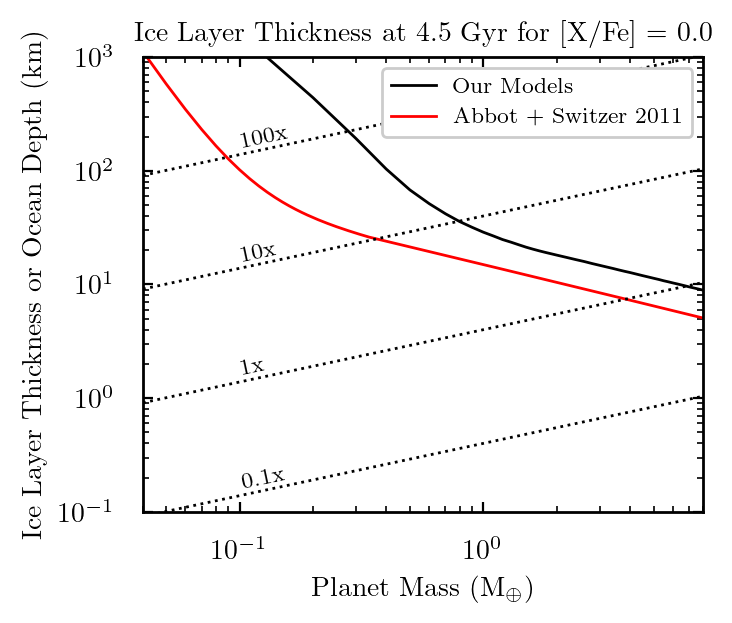

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3), dpi=200, constrained_layout=True)

ax.plot(conc_1_masses,ice_heights_conc_1/1e3, c='black', alpha=1.0, lw=1.0, label='Our Models')

ax.plot(planet_masses_test, ice_heights_test/1e3, c='red', alpha=1.0, lw=1.0, label='Abbot + Switzer 2011')
#ax.plot(planet_masses_test, ice_heights_test_CO2/1e3, c='red', ls='--',alpha=1.0, lw=1.0, label='Ice Layer Thickness at 4.5 Gyr')

ax.plot(planet_masses_test,ocean_depths_with_mass_01/1e3, c='black', alpha=1.0, lw=1.0, ls=':')
ax.plot(planet_masses_test,ocean_depths_with_mass/1e3, c='black', alpha=1.0, lw=1.0, ls=':')
ax.plot(planet_masses_test,ocean_depths_with_mass_10/1e3, c='black', alpha=1.0, lw=1.0, ls=':')
ax.plot(planet_masses_test,ocean_depths_with_mass_100/1e3, c='black', alpha=1.0, lw=1.0, ls=':')

# add labels to the ocean lines
ax.text(0.1, ocean_depths_with_mass_01[0]/3e2, rotation=12, s='0.1x', fontsize=8, color='black')
ax.text(0.1, ocean_depths_with_mass[0]/3e2, rotation=12, s='1x', fontsize=8, color='black')
ax.text(0.1, ocean_depths_with_mass_10[0]/3e2, rotation=12, s='10x', fontsize=8, color='black')
ax.text(0.1, ocean_depths_with_mass_100[0]/3e2, rotation=12, s='100x', fontsize=8, color='black')

ax.set_xlim(0.04,8)
ax.set_xscale('log')

ax.set_yscale('log')
ax.set_ylim(1e-1, 1e3)
#ax.grid()

ax.legend(loc='upper right', fontsize=8, frameon=True, framealpha=1.0)

#ax2 = ax.twinx()
#ax2.plot(conc_1_masses,conc_1_fluxes_at_time, c='red', alpha=1.0, lw=1.0)

ax.set_xlabel('Planet Mass (M$_\oplus$)')
ax.set_ylabel('Ice Layer Thickness or Ocean Depth (km)', color='black')
#ax2.set_ylabel('Surface Heat Flux (W/m²)', color='red')

ax.set_title('Ice Layer Thickness at 4.5 Gyr for [X/Fe] = 0.0', fontsize=10)

# now do it for all concentrations

In [25]:
mass_1_conc_all = []
mass_1_conc_all_times = []
mass_1_conc_all_tot_surf_heat_flux = []
# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if mass != 1.0:
        continue

    mass_1_conc_all_times.append(time)
    mass_1_conc_all.append(concentration)
    #print(mass, concentration)
    #print(total_surf_heat_flux)
    mass_1_conc_all_tot_surf_heat_flux.append(total_surf_heat_flux)

#print(mass_1_conc_all_times)
#mass_1_conc_1 = np.array(mass_1_conc_1[0])
#mass_1_conc_all_times = np.array(mass_1_conc_all_times)
#mass_1_conc_all_tot_surf_heat_flux = np.array(mass_1_conc_all_tot_surf_heat_flux)
#print(mass_1_conc_all_tot_surf_heat_flux)
#print(mass_1_conc_1)
print(len(mass_1_conc_all_tot_surf_heat_flux))
print(len(mass_1_conc_all_times))
print(len(mass_1_conc_all))

35
35
35


Text(0.5, 1.0, 'Surface Heat Flux for 1 M$_\\oplus$ Planet with Varying [X/Fe]')

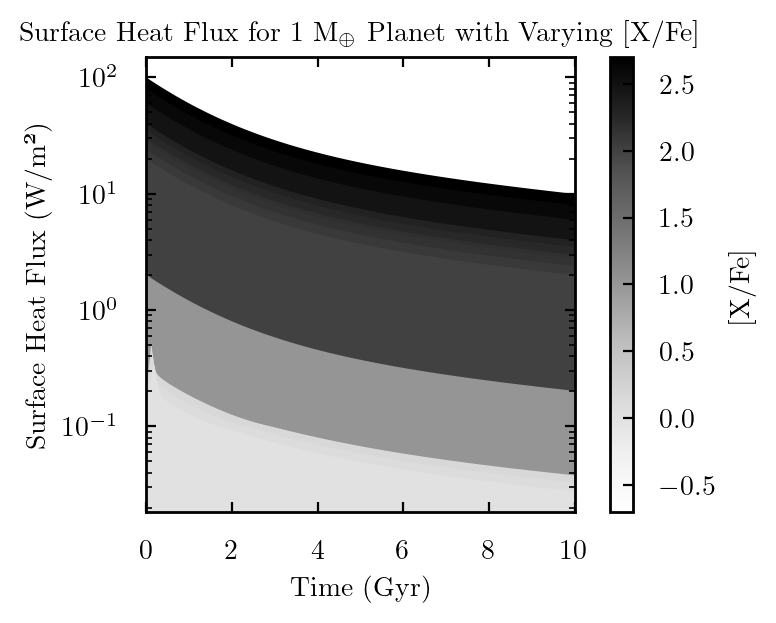

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Surface Heat Flux (W/m²)')

ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))

ax.set_yscale('log')
#for i in np.arange(0,len(mass_1_conc_all)):

# make a color map for the different concentrations
mass_1_conc_all_log = np.log10(np.array(mass_1_conc_all))
#print((mass_1_conc_all_log))
mass_1_conc_all_log[0] = -0.70
#print((mass_1_conc_all_log))
#print(np.min(mass_1_conc_all_log), np.max(mass_1_conc_all_log))

cmap = plt.get_cmap('Greys')
norm = plt.Normalize(vmin=np.min((mass_1_conc_all_log)), vmax=np.max((mass_1_conc_all_log)))
color_concentrations = cmap(norm((mass_1_conc_all_log)))

for i in reversed(range(1, len(mass_1_conc_all_times))):
    if np.isnan(np.log10(mass_1_conc_all_log[i])):
        continue
    #ax.plot(mass_1_conc_all_times[i], mass_1_conc_all_tot_surf_heat_flux[i], alpha=1.0, lw=1.0, c=color_concentrations[i-1])
    ax.fill_between(mass_1_conc_all_times[i], mass_1_conc_all_tot_surf_heat_flux[i], lw=0, alpha=1.0, color=color_concentrations[i])

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='[X/Fe]')

ax.set_title('Surface Heat Flux for 1 M$_\oplus$ Planet with Varying [X/Fe]', fontsize=10)

In [27]:
ice_heights_mass_1_conc_all = []
transport_regime_mass_1_conc_all = []

# for each flux with time curve, compute the ice height
for flux, conc in zip(mass_1_conc_all_tot_surf_heat_flux, mass_1_conc_all):
    grav = big_G * 1.0 * M_Earth / (R_Earth)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=False)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=False)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_1_conc_all.append(ice_heights_temp)
    transport_regime_mass_1_conc_all.append(transport_regime_temp)

In [28]:
# ocean height for a 1 earth mass planet is 4 km. 
# ocean height for a 1 earth mass planet with 10x the water content is 40 km.
xs = np.array([0.01, 0.1, 1, 2, 5, 10])
point_fours = np.ones(len(xs)) * 0.4
fours = np.ones(len(xs)) * 4
fourties = np.ones(len(xs)) * 40
fourhundreds = np.ones(len(xs)) * 400

0.0


Text(0.5, 1.0, 'Ice Height for 1 M$_\\oplus$ Planet, Varying [X/Fe]')

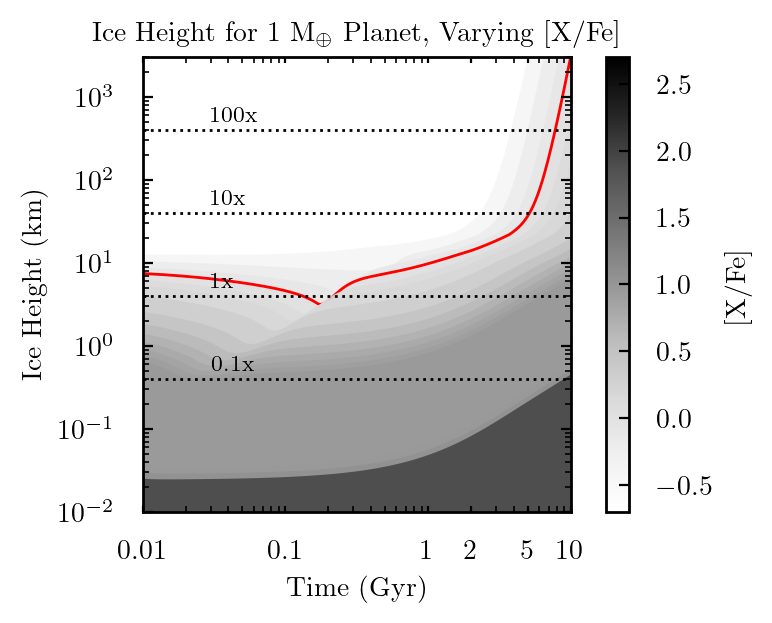

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Ice Height (km)')

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))

ax.set_yscale('log')
ax.set_ylim(1e-2, 3e3)
ax.set_xscale('log')
ax.set_xlim(1e-2, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
ax.set_xticks([0.01, 0.1, 1, 2, 5, 10])
ax.tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5', '10'])

#for i in np.arange(0,len(mass_1_conc_all)):

for i in range(0, len(mass_1_conc_all_times)):
    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_concentrations[i-1])

    ax.fill_between(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i])/1e3, lw=0, alpha=0.9, color=color_concentrations[i])

    if (mass_1_conc_all_log[i]) == 0.0:
        print(mass_1_conc_all_log[i])
        ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i])/1e3, lw=1, alpha=1.0, color='red', zorder=1)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='[X/Fe]')

ax.plot(xs, point_fours, ls=':', lw=1.0, c='black', label='Ocean Height (0.4 km)')
ax.plot(xs, fours, ls=':', lw=1.0, c='black', label='Ocean Height (4 km)')
ax.plot(xs, fourties, ls=':', lw=1.0, c='black', label='Ocean Height (40 km)')
ax.plot(xs, fourhundreds, ls=':', lw=1.0, c='black', label='Ocean Height (400 km)')

# and add labels to the ocean height lines (0.1x, 1x, 10x, 100x) at x=0.01
ax.text(0.03, 0.45, '0.1x', fontsize=8, color='black', verticalalignment='bottom')
ax.text(0.03, 4.5, '1x', fontsize=8, color='black', verticalalignment='bottom')
ax.text(0.03, 45, '10x', fontsize=8, color='black', verticalalignment='bottom')
ax.text(0.03, 450, '100x', fontsize=8, color='black', verticalalignment='bottom')

ax.set_title('Ice Height for 1 M$_\oplus$ Planet, Varying [X/Fe]', fontsize=10)

# now do it for all masses

(-1.0, 10.0)

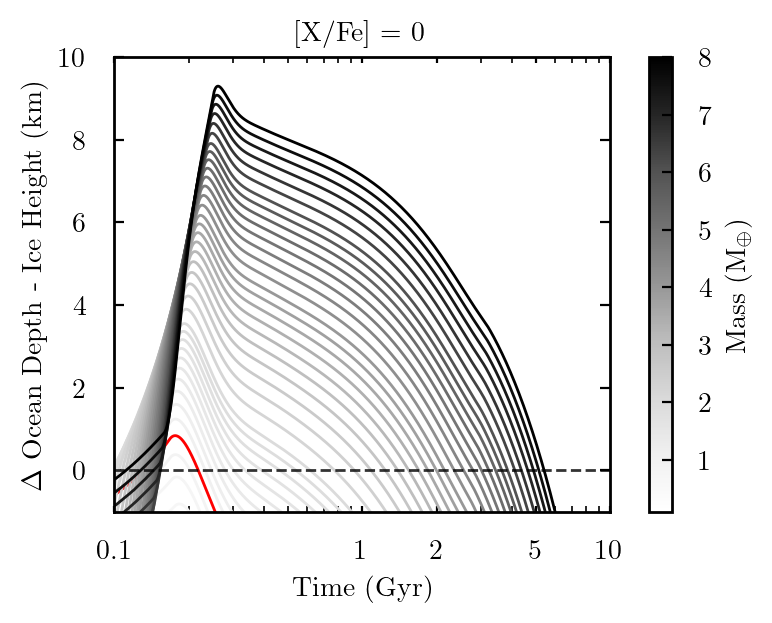

In [30]:
# ice layer vs time for a given concentration, with mass as the color bar
# first: surface heat flux vs time for a given concentration
mass_all_conc_1 = []
mass_all_conc_1_times = []
mass_all_conc_1_tot_surf_heat_flux = []
# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if concentration != 1.0:
        continue

    mass_all_conc_1_times.append(time)
    mass_all_conc_1.append(mass)
    #print(mass, concentration)
    #print(total_surf_heat_flux)
    mass_all_conc_1_tot_surf_heat_flux.append(total_surf_heat_flux)

#print(len(mass_all_conc_1_tot_surf_heat_flux))
#print(len(mass_all_conc_1_times))
#print(len(mass_all_conc_1))

#fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)
#
#ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Surface Heat Flux (W/m²)')
#
#ax.set_xlim(np.min(mass_all_conc_1_times[0]), np.max(mass_all_conc_1_times[0]))
#
#ax.set_yscale('log')
#ax.set_ylim(1e-2, 1e0)
#for i in np.arange(0,len(mass_1_conc_all)):

# make a color map for the different concentrations

#print(np.min(mass_all_conc_1), np.max(mass_all_conc_1))

cmap = plt.get_cmap('Greys')
norm = plt.Normalize(vmin=np.min((mass_all_conc_1)), vmax=np.max((mass_all_conc_1)))
color_masses = cmap(norm((mass_all_conc_1)))

# plot in reverse order so the smallest mass is on top of the plot
#for i in reversed(np.arange(0, len(mass_all_conc_1_times))):
#    if np.isnan(np.log10(mass_all_conc_1[i])):
#        continue
#    #ax.plot(mass_all_conc_1_times[i], mass_all_conc_1_tot_surf_heat_flux[i], alpha=1.0, lw=1.0, c=color_masses[i])
#    ax.fill_between(mass_all_conc_1_times[i], mass_all_conc_1_tot_surf_heat_flux[i], lw=0, alpha=0.9, color=color_masses[i])#

#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')#

#ax.set_title('Varying Planet Mass, [X/Fe] = 0', fontsize=10)

# now compute the ice heights for the range of planet masses at [X/Fe] = 0.0

ice_heights_mass_all_conc_1 = []
transport_regime_mass_all_conc_1 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_1_tot_surf_heat_flux, mass_all_conc_1):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=False)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=False)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_1.append(ice_heights_temp)
    transport_regime_mass_all_conc_1.append(transport_regime_temp)

# now plot the ice heights
#fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)
#
#ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Ice Height (km)')
#
##ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))
#
#ax.set_yscale('log')
#ax.set_ylim(1e-0, 3e3)
#ax.set_xscale('log')
#ax.set_xlim(1e-1, 1e1)
## set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
#ax.set_xticks([0.1, 1, 2, 5, 10])
#ax.tick_params(axis='x', which='major', length=2)
## add lables to the x ticks
#ax.set_xticklabels(['0.1', '1', '2', '5', '10'])

#for i in np.arange(0,len(mass_1_conc_all)):

#for i in np.arange(0, len(mass_all_conc_1_times)):

    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

#    ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])

#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot ocean depths as function of mass
#depths = 4.0 * np.array(mass_all_conc_1)**(1 - 2*0.27)  # in km
#for i, depth in enumerate(depths):
#    ax.axhline(y=depth, ls=':', lw=1.0, c=color_masses[i], alpha=0.8)

# make a legend for the ocean depths
#from matplotlib.lines import Line2D
#legend_elements = [Line2D([0], [0], color='black', lw=1, ls=':', label='Ocean Depth')]
#ax.legend(handles=legend_elements, loc='upper left', fontsize=8, frameon=True, framealpha=1.0)

#ax.set_title('Ice Height for Varying Planet Mass, [X/Fe] = 0', fontsize=10)

# now plot the ice heights
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Ice to Ocean Ratio')
#ax.set_ylabel('Ice Height (km)')
ax.set_ylabel(r'$\Delta$ Ocean Depth - Ice Height (km)')

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))


#ax.set_ylim(-1e1, 1e1)
#ax.set_yscale('log'); ax.set_ylim(1e-1, 2e1)
ax.set_xscale('log')
ax.set_xlim(1e-1, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
ax.set_xticks([0.1, 1, 2, 5, 10])
ax.tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
ax.set_xticklabels(['0.1', '1', '2', '5', '10'])

depths = 4.0 * np.array(mass_all_conc_1)**(1 - 2*0.27)  # in km

for i in np.arange(0, len(mass_all_conc_1_times)):
    #print(depths[i])
    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, depths[i], lw=0, alpha=0.5, color=color_masses[i])
    
    # plot the ratio of the ice depths to the ocean depths
    #ax.plot(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3 / depths[i], lw=1.0, alpha=0.5, color=color_masses[i])

    # plot the difference between the ice heights and the ocean depths
    ax.plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])

    if mass_all_conc_1[i] == 1.0:
        ax.plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=1.0, alpha=1.0, color='red')


plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot a dashed line at y=1 to indicate where the ice height equals the ocean depth
ax.axhline(y=0, ls='--', lw=1.0, c='black', alpha=0.8)

#ax.set_title('Ocean Depth Minus Ice Height for Varying Planet Mass, [X/Fe] = 0', fontsize=10)
ax.set_title('[X/Fe] = 0', fontsize=10)
ax.set_ylim(-1, 10)

# and now the concentration 10x (+1 dex)

Text(0.5, 1.0, '[X/Fe] = +1')

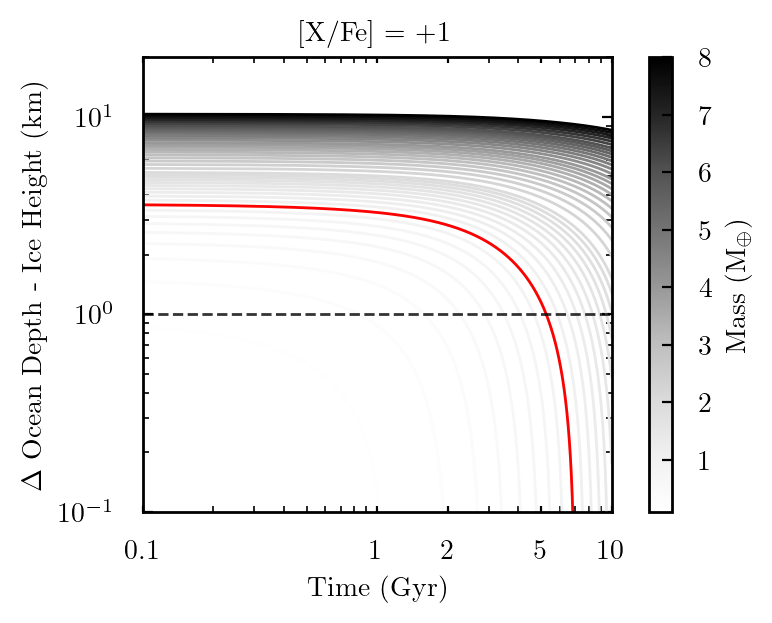

In [31]:
# ice layer vs time for a given concentration, with mass as the color bar
# first: surface heat flux vs time for a given concentration
mass_all_conc_10 = []
mass_all_conc_10_times = []
mass_all_conc_10_tot_surf_heat_flux = []
# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if concentration != 10.0:
        continue

    mass_all_conc_10_times.append(time)
    mass_all_conc_10.append(mass)
    #print(mass, concentration)
    #print(total_surf_heat_flux)
    mass_all_conc_10_tot_surf_heat_flux.append(total_surf_heat_flux)

#print(len(mass_all_conc_10_tot_surf_heat_flux))
#print(len(mass_all_conc_10_times))
#print(len(mass_all_conc_10))
#fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)
#
#ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Surface Heat Flux (W/m²)')
#
#ax.set_xlim(np.min(mass_all_conc_10_times[0]), np.max(mass_all_conc_10_times[0]))
#
#ax.set_yscale('log')
#ax.set_ylim(1e-2, 1e1)
#for i in np.arange(0,len(mass_1_conc_all)):

# make a color map for the different concentrations

#print(np.min(mass_all_conc_10), np.max(mass_all_conc_10))

cmap = plt.get_cmap('Greys')
norm = plt.Normalize(vmin=np.min((mass_all_conc_10)), vmax=np.max((mass_all_conc_10)))
color_masses = cmap(norm((mass_all_conc_10)))

# plot in reverse order so the smallest mass is on top of the plot
#for i in reversed(np.arange(0, len(mass_all_conc_10_times))):
#    if np.isnan(np.log10(mass_all_conc_10[i])):
#        continue
#    #ax.plot(mass_all_conc_10_times[i], mass_all_conc_10_tot_surf_heat_flux[i], alpha=1.0, lw=1.0, c=color_masses[i])
#    ax.fill_between(mass_all_conc_10_times[i], mass_all_conc_10_tot_surf_heat_flux[i], lw=0, alpha=0.9, color=color_masses[i])
#
#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')
#
#ax.set_title('Varying Planet Mass, [X/Fe] = +1', fontsize=10)

# now compute the ice heights for the range of planet masses at [X/Fe] = 1.0

ice_heights_mass_all_conc_10 = []
transport_regime_mass_all_conc_10 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_10_tot_surf_heat_flux, mass_all_conc_10):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=False)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=False)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_10.append(ice_heights_temp)
    transport_regime_mass_all_conc_10.append(transport_regime_temp)

    # now plot the ice heights
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'$\Delta$ Ocean Depth - Ice Height (km)')

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))

ax.set_yscale('log')
ax.set_ylim(1e-1, 2e1)
ax.set_xscale('log')
ax.set_xlim(1e-1, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
ax.set_xticks([0.1, 1, 2, 5, 10])
ax.tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
ax.set_xticklabels(['0.1', '1', '2', '5', '10'])

depths = 4.0 * np.array(mass_all_conc_10)**(1 - 2*0.27)  # in km

for i in np.arange(0, len(mass_all_conc_10_times)):

    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

    #ax.fill_between(mass_all_conc_10_times[i], np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
    ax.plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])

    if mass_all_conc_10[i] == 1.0:
        ax.plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=1.0, alpha=1.0, color='red')


plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot a dashed line at y=1 to indicate where the ice height equals the ocean depth
ax.axhline(y=1, ls='--', lw=1.0, c='black', alpha=0.8)

ax.set_title('[X/Fe] = +1', fontsize=10)

# test the CO2 layer on top for the 0.0 cases

Text(0.5, 1.0, '[X/Fe] = 0 with CO$_2$ layer')

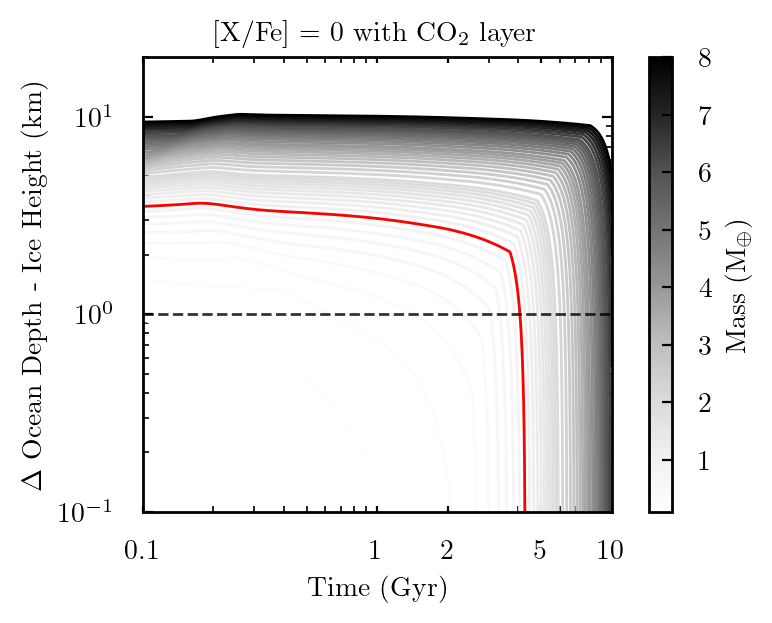

In [32]:
ice_heights_mass_all_conc_1_CO2 = []
transport_regime_mass_all_conc_1_CO2 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_1_tot_surf_heat_flux, mass_all_conc_1):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=220)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=220)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_1_CO2.append(ice_heights_temp)
    transport_regime_mass_all_conc_1_CO2.append(transport_regime_temp)

# now plot the ice heights
#fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)
#
#ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Ice Height (km)')
#
##ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))
#
#ax.set_yscale('log')
#ax.set_ylim(1e-0, 3e3)
#ax.set_xscale('log')
#ax.set_xlim(1e-1, 1e1)
## set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
#ax.set_xticks([0.1, 1, 2, 5, 10])
#ax.tick_params(axis='x', which='major', length=2)
## add lables to the x ticks
#ax.set_xticklabels(['0.1', '1', '2', '5', '10'])
#
##for i in np.arange(0,len(mass_1_conc_all)):
#
#for i in np.arange(0, len(mass_all_conc_1_times)):
#
#    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])
#
#    ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1_CO2[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
#
#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')
#
## plot ocean depths as function of mass
#depths = 4.0 * np.array(mass_all_conc_1)**(1 - 2*0.27)  # in km
#for i, depth in enumerate(depths):
#    ax.axhline(y=depth, ls=':', lw=1.0, c=color_masses[i], alpha=0.8)

# make a legend for the ocean depths
#from matplotlib.lines import Line2D
#legend_elements = [Line2D([0], [0], color='black', lw=1, ls=':', label='Ocean Depth')]
#ax.legend(handles=legend_elements, loc='upper left', fontsize=8, frameon=True, framealpha=1.0)

ax.set_title('Ice Height for Varying Planet Mass with CO$_2$, [X/Fe] = 0', fontsize=10)

# now plot the ice heights
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
#ax.set_ylabel('Ice to Ocean Ratio')
#ax.set_ylabel('Ice Height (km)')
ax.set_ylabel(r'$\Delta$ Ocean Depth - Ice Height (km)')

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))


#ax.set_ylim(-1e1, 1e1)
ax.set_yscale('log'); ax.set_ylim(1e-1, 2e1)
ax.set_xscale('log')
ax.set_xlim(1e-1, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
ax.set_xticks([0.1, 1, 2, 5, 10])
ax.tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
ax.set_xticklabels(['0.1', '1', '2', '5', '10'])

depths = 4.0 * np.array(mass_all_conc_1)**(1 - 2*0.27)  # in km

for i in np.arange(0, len(mass_all_conc_1_times)):
    #print(depths[i])
    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, depths[i], lw=0, alpha=0.5, color=color_masses[i])
    
    # plot the ratio of the ice depths to the ocean depths
    #ax.plot(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3 / depths[i], lw=1.0, alpha=0.5, color=color_masses[i])

    # plot the difference between the ice heights and the ocean depths
    ax.plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1_CO2[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])

    if mass_all_conc_1[i] == 1.0:
        ax.plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1_CO2[i])/1e3, lw=1.0, alpha=1.0, color='red')


plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot a dashed line at y=1 to indicate where the ice height equals the ocean depth
ax.axhline(y=1, ls='--', lw=1.0, c='black', alpha=0.8)

#ax.set_title('Ocean Depth Minus Ice Height for Varying Planet Mass, [X/Fe] = 0', fontsize=10)
ax.set_title('[X/Fe] = 0 with CO$_2$ layer', fontsize=10)

Text(0.5, 1.0, '[X/Fe] = +1 with CO$_2$ layer')

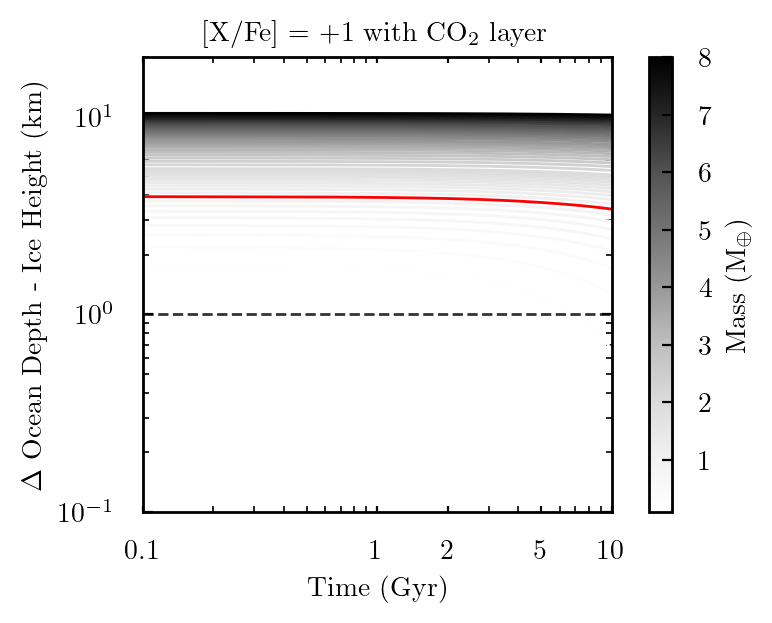

In [33]:
# and the +1 dex scenario with CO2 layer
# ice layer vs time for a given concentration, with mass as the color bar
# first: surface heat flux vs time for a given concentration

# now compute the ice heights for the range of planet masses at [X/Fe] = 1.0 with a CO2 layer

ice_heights_mass_all_conc_10_CO2 = []
transport_regime_mass_all_conc_10_CO2 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_10_tot_surf_heat_flux, mass_all_conc_10):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=220)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=220)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_10_CO2.append(ice_heights_temp)
    transport_regime_mass_all_conc_10_CO2.append(transport_regime_temp)

    # now plot the ice heights
fig, ax = plt.subplots(1, 1, figsize=(3.75, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'$\Delta$ Ocean Depth - Ice Height (km)')

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))

ax.set_yscale('log')
ax.set_ylim(1e-1, 2e1)
ax.set_xscale('log')
ax.set_xlim(1e-1, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
ax.set_xticks([0.1, 1, 2, 5, 10])
ax.tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
ax.set_xticklabels(['0.1', '1', '2', '5', '10'])

depths = 4.0 * np.array(mass_all_conc_10)**(1 - 2*0.27)  # in km

for i in np.arange(0, len(mass_all_conc_10_times)):

    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

    #ax.fill_between(mass_all_conc_10_times[i], np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
    ax.plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])

    if mass_all_conc_10[i] == 1.0:
        ax.plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=1.0, alpha=1.0, color='red')


plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot a dashed line at y=1 to indicate where the ice height equals the ocean depth
ax.axhline(y=1, ls='--', lw=1.0, c='black', alpha=0.8)

ax.set_title('[X/Fe] = +1 with CO$_2$ layer', fontsize=10)

Text(0.95, 0.96, '(d)')

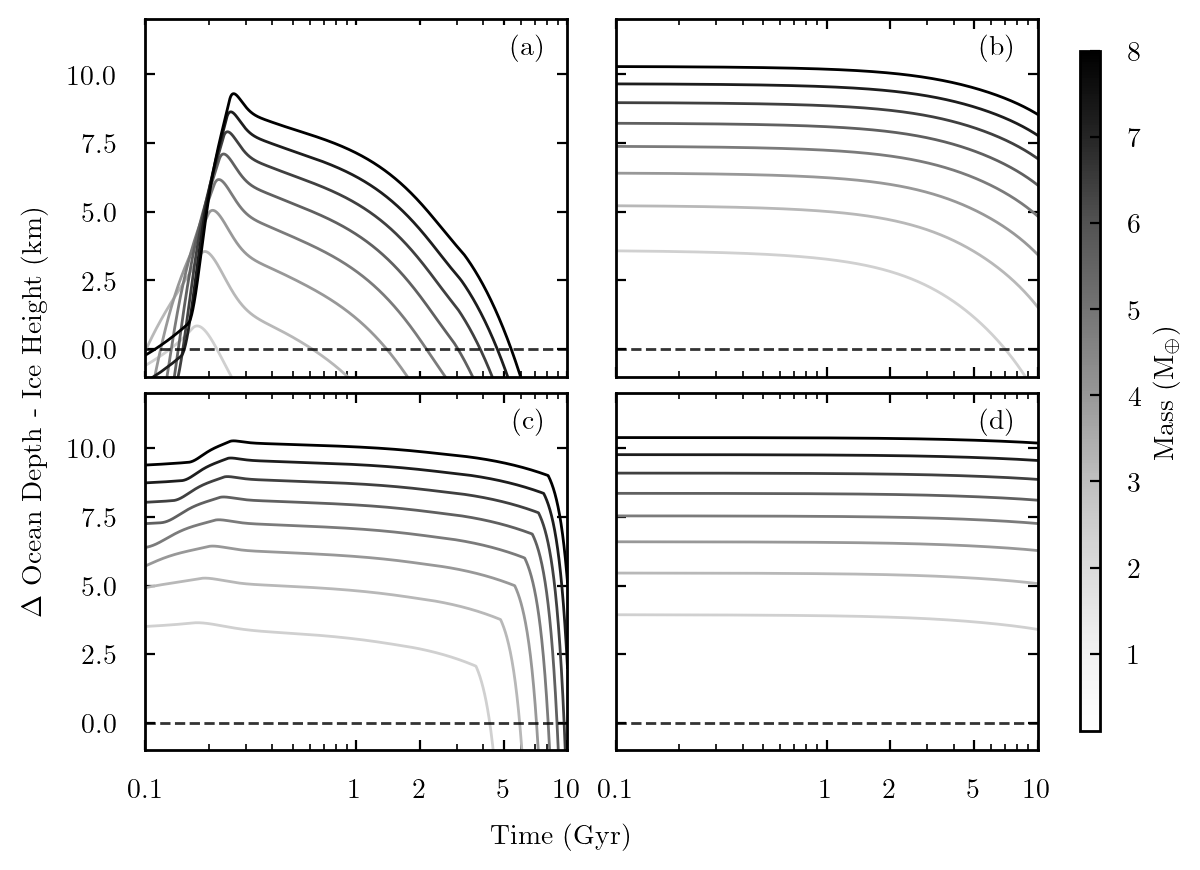

In [45]:
# ice layer vs time for a given concentration, with mass as the color bar
# first: surface heat flux vs time for a given concentration
mass_all_conc_1 = []
mass_all_conc_1_times = []
mass_all_conc_1_tot_surf_heat_flux = []
# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if concentration != 1.0:
        continue

    mass_all_conc_1_times.append(time)
    mass_all_conc_1.append(mass)
    #print(mass, concentration)
    #print(total_surf_heat_flux)
    mass_all_conc_1_tot_surf_heat_flux.append(total_surf_heat_flux)

cmap = plt.get_cmap('Greys')
norm = plt.Normalize(vmin=np.min((mass_all_conc_1)), vmax=np.max((mass_all_conc_1)))
#color_masses = cmap(norm((mass_all_conc_1)))
color_masses = cmap(norm((mass_all_conc_1)) * 0.8 + 0.2)

# now compute the ice heights for the range of planet masses at [X/Fe] = 0.0

ice_heights_mass_all_conc_1 = []
transport_regime_mass_all_conc_1 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_1_tot_surf_heat_flux, mass_all_conc_1):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    #print(conc)
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=False)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=False)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_1.append(ice_heights_temp)
    transport_regime_mass_all_conc_1.append(transport_regime_temp)

# plot the ice heights
fig, axs = plt.subplots(2, 2, figsize=(5, 4), dpi=200, constrained_layout=True, sharex=True, sharey=True)

# make a xlabel for the full figure
fig.text(0.5, -0.04, 'Time (Gyr)', ha='center', fontsize=10)
# make a ylabel for the full figure
fig.text(-0.04, 0.5, r'$\Delta$ Ocean Depth - Ice Height (km)', va='center', rotation='vertical', fontsize=10)

#ax.set_xlim(np.min(mass_1_conc_all_times[0]), np.max(mass_1_conc_all_times[0]))

#ax.set_ylim(-1e1, 1e1)
#axs[0, 0].set_yscale('log'); 
axs[0, 0].set_ylim(-1, 1.2e1)
axs[0, 0].set_xscale('log')
axs[0, 0].set_xlim(1e-1, 1e1)
# set x ticks to be 0.01, 0.1, 1, 2, 5, 10, with no tick length
axs[0, 0].set_xticks([0.1, 1, 2, 5, 10])
axs[0, 0].tick_params(axis='x', which='major', length=2)
# add lables to the x ticks
axs[0, 0].set_xticklabels(['0.1', '1', '2', '5', '10'])

depths = 4.0 * np.array(mass_all_conc_1)**(1 - 2*0.27)  # in km

for i in np.arange(0, len(mass_all_conc_1_times)):
    # only plot masses 1, 3, 5, 7
    if mass_all_conc_1[i] in [1, 2, 3, 4, 5, 6, 7, 8]:
        # plot the difference between the ice heights and the ocean depths
        axs[0, 0].plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])

       # if mass_all_conc_1[i] == 1.0:
       #     axs[0, 0].plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=1.0, alpha=1.0, color='red')


#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

# plot a dashed line at y=0 to indicate where the ice height equals the ocean depth
axs[0,0].axhline(y=0, ls='--', lw=1.0, c='black', alpha=0.8)

# ice layer vs time for a given concentration, with mass as the color bar
# first: surface heat flux vs time for a given concentration
mass_all_conc_10 = []
mass_all_conc_10_times = []
mass_all_conc_10_tot_surf_heat_flux = []
# for a given mass and concentration, make an array with the total surface heat fluxes as a function of time
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, total_surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes, total_surf_heat_fluxes):
    if concentration != 10.0:
        continue

    mass_all_conc_10_times.append(time)
    mass_all_conc_10.append(mass)
    #print(mass, concentration)
    #print(total_surf_heat_flux)
    mass_all_conc_10_tot_surf_heat_flux.append(total_surf_heat_flux)

cmap = plt.get_cmap('Greys')
norm = plt.Normalize(vmin=np.min((mass_all_conc_10)), vmax=np.max((mass_all_conc_10)))
#color_masses = cmap(norm((mass_all_conc_10)))
# limit the color map to start at a darker color, so they all show up better on the plot
color_masses = cmap(norm((mass_all_conc_10)) * 0.8 + 0.2)

# now compute the ice heights for the range of planet masses at [X/Fe] = 1.0

ice_heights_mass_all_conc_10 = []
transport_regime_mass_all_conc_10 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_10_tot_surf_heat_flux, mass_all_conc_10):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=False)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=False)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_10.append(ice_heights_temp)
    transport_regime_mass_all_conc_10.append(transport_regime_temp)

for i in np.arange(0, len(mass_all_conc_10_times)):

    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])
    if mass_all_conc_10[i] in [1, 2, 3, 4, 5, 6, 7, 8]:

    #ax.fill_between(mass_all_conc_10_times[i], np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
        axs[0,1].plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])

    #if mass_all_conc_10[i] == 1.0:
    #    axs[0,1].plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10[i])/1e3, lw=1.0, alpha=1.0, color='red')

#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs[0,1], label='Mass (M$_\oplus$)')

# plot a dashed line at y=0 to indicate where the ice height equals the ocean depth
axs[0,1].axhline(y=0, ls='--', lw=1.0, c='black', alpha=0.8)


# CO2 LAYERS

ice_heights_mass_all_conc_1_CO2 = []
transport_regime_mass_all_conc_1_CO2 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_1_tot_surf_heat_flux, mass_all_conc_1):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=220)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=220)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_1_CO2.append(ice_heights_temp)
    transport_regime_mass_all_conc_1_CO2.append(transport_regime_temp)

for i in np.arange(0, len(mass_all_conc_1_times)):
    #print(depths[i])
    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])

    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3, depths[i], lw=0, alpha=0.5, color=color_masses[i])
    
    # plot the ratio of the ice depths to the ocean depths
    #ax.plot(mass_all_conc_1_times[i], np.array(ice_heights_mass_all_conc_1[i])/1e3 / depths[i], lw=1.0, alpha=0.5, color=color_masses[i])

    # plot the difference between the ice heights and the ocean depths
    if mass_all_conc_1[i] in [1, 2, 3, 4, 5, 6, 7, 8]:

        axs[1,0].plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1_CO2[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])
    #ax.fill_between(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])

    #if mass_all_conc_1[i] == 1.0:
    #    axs[1,0].plot(mass_all_conc_1_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_1_CO2[i])/1e3, lw=1.0, alpha=1.0, color='red')

# plot a dashed line at y=0 to indicate where the ice height equals the ocean depth
axs[1,0].axhline(y=0, ls='--', lw=1.0, c='black', alpha=0.8)

# now compute the ice heights for the range of planet masses at [X/Fe] = 1.0 with a CO2 layer

ice_heights_mass_all_conc_10_CO2 = []
transport_regime_mass_all_conc_10_CO2 = []

# for each flux with time curve, compute the ice height
for flux, mass in zip(mass_all_conc_10_tot_surf_heat_flux, mass_all_conc_10):
    r_planet = R_Earth * mass**0.27
    grav = big_G * mass * M_Earth / (r_planet)**2  # assuming Earth-like mass and radius
    
    # make an array of the ice heights for each flux with time curve at the given concentration
    # name the temporary array 
    ice_heights_temp = []
    transport_regime_temp = []

    for flx in flux:
        test_H_cond = H_cond(T_H=260, F=flx, A=651, T_0=220)
        test_H_conv = H_conv(T_H=260, F=flx, A=651, g=grav, T_0=220)

        if test_H_conv > test_H_cond:
            #print(f"Convection dominates: H = {test_H_conv:.2f} m")
            ice_heights_temp.append(test_H_conv)
            transport_regime_temp.append('convection')
        else:
            #print(f"Conduction dominates: H = {test_H_cond:.2f} m")
            ice_heights_temp.append(test_H_cond)
            transport_regime_temp.append('conduction')

    ice_heights_mass_all_conc_10_CO2.append(ice_heights_temp)
    transport_regime_mass_all_conc_10_CO2.append(transport_regime_temp)

for i in np.arange(0, len(mass_all_conc_10_times)):

    #ax.plot(mass_1_conc_all_times[i], np.array(ice_heights_mass_1_conc_all[i-1])/1e3, alpha=1.0, lw=1.0, c=color_masses[i-1])
    if mass_all_conc_10[i] in [1, 2, 3, 4, 5, 6, 7, 8]:

    #ax.fill_between(mass_all_conc_10_times[i], np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=0, alpha=0.5, color=color_masses[i])
        axs[1,1].plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=1.0, alpha=1.0, color=color_masses[i])

    #if mass_all_conc_10[i] == 1.0:
    #    axs[1,1].plot(mass_all_conc_10_times[i],  depths[i] - np.array(ice_heights_mass_all_conc_10_CO2[i])/1e3, lw=1.0, alpha=1.0, color='red')

#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs[1,1], label='Mass (M$_\oplus$)')

# plot a single colorbar for the entire figure, with the label 'Mass (M$_\oplus$)' and a font size of 10
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.85])
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label('Mass (M$_\oplus$)', fontsize=10)
cbar.ax.tick_params(labelsize=10)

# plot a dashed line at y=0 to indicate where the ice height equals the ocean depth
axs[1,1].axhline(y=0, ls='--', lw=1.0, c='black', alpha=0.8)

# in each panel in the top right corner, add a letter (a), (b), (c), (d) for the four panels, with a font size of 10
axs[0,0].text(0.95, 0.96, '(a)', transform=axs[0,0].transAxes, fontsize=10, va='top', ha='right')
axs[0,1].text(0.95, 0.96, '(b)', transform=axs[0,1].transAxes, fontsize=10, va='top', ha='right')
axs[1,0].text(0.95, 0.96, '(c)', transform=axs[1,0].transAxes, fontsize=10, va='top', ha='right')
axs[1,1].text(0.95, 0.96, '(d)', transform=axs[1,1].transAxes, fontsize=10, va='top', ha='right')


 # we need to be able to determine the phase of the ice at a given pressure and temperature (depth).

In [35]:
def ice_phase(P_MPa, T_K):
    """
    Determine stable ice phase from pressure and temperature.

    Returns:
        phase name
        density
        thermal properties
    """
    A = 651  # W/m², thermal conductivity parameter
    # -------------------------
    # Phase boundaries
    # -------------------------

    # Ih - III
    if 238 <= T_K <= 251:
        P_Ih_III = 212 - 3*(T_K-238)/13
    elif T_K > 251:
        P_Ih_III = 209
    else:
        P_Ih_III = 212

    # II - III
    if 238 <= T_K <= 248:
        P_II_III = 212 + 13.2*(T_K-238)
    else:
        P_II_III = np.inf

    # III - V
    if 248 <= T_K <= 256:
        P_III_V = 344 + 0.75*(T_K-248)
    elif T_K > 256:
        P_III_V = 350
    else:
        P_III_V = 344

    # V - VI
    P_V_VI = 620 + 12*(T_K-218)/55

    # VI - VII
    P_VI_VII = 2100 + 116*(T_K-278)/77

    # -------------------------
    # Select phase
    # -------------------------

    if P_MPa >= P_VI_VII:
        return {
            "phase":"VII",
            "rho":1463, # from Fu et al. 2010 from Hemley et al. 1987
            "k":A / T_K, # 3.5 W/m/K thermal conductivity of ice VII ???
            "alpha":1.56e-4,
            "eta":1e9
        }

    elif P_MPa >= P_V_VI:
        return {
            "phase":"VI",
            "rho":1310,
            "k":A / T_K, # 3.4 W/m/K thermal conductivity of ice VI ???
            "alpha":1.56e-4, # 2.43e-4 1/K thermal expansivity of ice VI from Journaux et al. 2020
            "eta":1e10
        }

    elif P_MPa >= P_III_V:
        return {
            "phase":"V",
            "rho":1240,
            "k":A / T_K, # 3.2 W/m/K thermal conductivity of ice V ???
            "alpha":1.56e-4, # 1.78e-4 1/K thermal expansivity of ice V from Journaux et al. 2020
            "eta":1e11
        }

    elif T_K < 248 and P_Ih_III <= P_MPa < P_II_III:
        return {
            "phase":"II",
            "rho":1170,
            "k":A / T_K, # ???
            "alpha":1.56e-4, # 2.07e-4 1/K thermal expansivity of ice V from Journaux et al. 2020
            "eta":5e12
        }

    elif P_MPa >= P_Ih_III:
        return {
            "phase":"III",
            "rho":1160,
            "k":A / T_K, # 3.0 W/m/K thermal conductivity of ice III ?
            "alpha":1.56e-4, # 2.14e-4 1/K thermal expansivity of ice III from Journaux et al. 2020
            "eta":1e12
        }

    else:
        return {
            "phase":"Ih",
            "rho":917,
            "k":A / T_K, # 3.3 W/m/K thermal conductivity of ice Ih
            "alpha":1.56e-4,
            "eta":1e13
        }
    


In [36]:
def temperature_profile(z, H, H_lid, T0, Tc, TH):

    if z <= H_lid:
        return T0 * (Tc / T0)**(z / H_lid)

    else:
        return Tc + (TH - Tc) * (z - H_lid) / (H - H_lid)

In [37]:
def ice_profile(H_cond,
                H_conv,
                H_lid,
                F,
                T_c,
                T_H=273,
                g=9.81,
                A=651,
                dz=100,
                T_0=False):
    
    if H_conv is None:
        H = H_cond
    else:
        H = H_conv + H_lid

    # create depth grid
    z = np.arange(0,H+dz,dz)
    #z_conv = np.arange(H_lid,H+dz,dz)
    #z_lid = np.arange(0,H_lid+dz,dz)
    P = np.zeros_like(z,dtype=float)
    #T_cond = np.zeros_like(z,dtype=float)
    #T_conv = np.zeros_like(z,dtype=float)
    T = np.zeros_like(z,dtype=float)
    rho = np.zeros_like(z,dtype=float)
    phase = []
    k = []
    alpha = []
    eta = []

    # given heat flux is constant throughout the ice layer, 
    # and the surface temperature is determined by the Stefan-Boltzmann law.
    if T_0 is False:
        T_0 = (F / sigma_SB) ** 0.25 
    else:
        T_0 = T_0  # use provided surface temperature

    # initialize the surface
    P[0]=0
    T[0]=T_0
    #T_cond[0]=T_0
    #T_conv[0]=T_0
    rho[0]=917
    phase.append("Ih")

    # set bottom temperature to T_H
    #T[-1]=T_H
    print((T_c + T_H) / 2)
    # and now integrate over the depth to compute the temperature, pressure, density, and phase at each depth.
    for i in range(1,len(z)):
        depth = z[i]

        # fully conductive regime:
        # exponential conductive profile for the temperature in the conductive layer(s).
        if H_conv is None:
            T[i] = T_0 *( T_H / T_0 ) ** (depth / H) # T_0*np.exp(F*depth/A)
        # mixed regime
        # otherwise, use the height of the lid and compute the conductuve temperature profile
        else: # H_conv is not None
            # piece together the lid and the convective layer
            if depth <= H_lid:
                T[i] = T_0 *( T_c / T_0 ) ** (depth / H_lid)
            # the temperature across the convective layer
            else:
                # assume a constant temperature.
                    # there are 'transitions' between the conductive and convective layers, 
                    # but for now, we will just see discontinuities.
                #T[i] = ( T_c + T_H ) / 2
                # or, for maybe a linear profile across the convective layer, we can use:
                T[i] = T_c + (T_H - T_c) * (depth - H_lid) / H_conv
            T[-1] = T_H  # set the bottom temperature to T_H
        #T[i] = temperature_profile(depth, H, H_lid, T_0, T_c, T_H)

        props = ice_phase(P[i-1],T[i])
        phase.append(props["phase"])
        rho[i]=props["rho"]
        P[i]=P[i-1] + rho[i]*g*dz/1e6
        k.append(props["k"])
        alpha.append(props["alpha"])
        eta.append(props["eta"])

    return {
        "depth":z,
        "pressure":P,
        "temperature":T,
        "density":rho,
        "phase":phase,
        "k":k,
        "alpha":alpha,
        "eta":eta
        }

In [38]:
# test: produce a pressure and temperature curves.
# P + T diagrams from new ice_profile function
test_T_high = 260 # K at bottom
test_T_c = 238 # K at top of convective layer
test_z_range = np.arange(0, 30000, 10) # m directly!
# Color map for all ice phases
phase_colors = {
    'Ih': 'lightblue',
    'II': 'purple',
    'III': 'green',
    'V': 'orange',
    'VI': 'red',
    'VII': 'darkred',
    'liquid': 'deepskyblue'
}

# Use corrected phase function
profile = ice_profile(H_cond=max(test_z_range), H_conv=max(test_z_range)/3, H_lid=max(test_z_range)*2/3, F=0.087, T_c=test_T_c, T_H=test_T_high, g=9.81, dz=100, T_0=False)
phase = profile['phase']

#print(profile['temperature'][-1])
#print(profile['pressure'][-1])
#print(phase[-1])


249.0


Surface Pressure: 0.0 MPa, Surface Temperature: 35.19466850626155 K, Phase: Ih, eta: 10000000000000.0 Pa.s, k: 18.321128687911088 W/m/K, alpha: 0.000156 1/K
Bottom Pressure: 285.71428799999944 MPa, Bottom Temperature: 260.0 K, Phase: III, eta: 1000000000000.0 Pa.s, k: 2.503846153846154 W/m/K, alpha: 0.000156 1/K


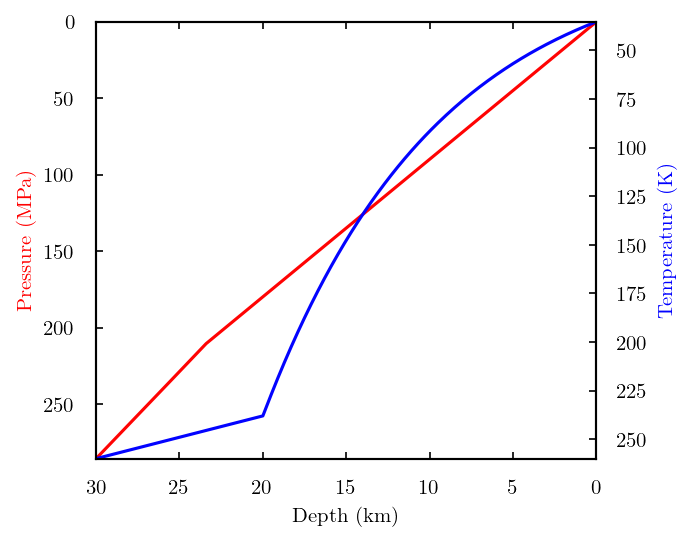

In [39]:

fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.5), dpi=150, constrained_layout=True)

ax.plot(profile['depth']/1000, profile['pressure'], c='red', lw=1.5, alpha=0.99)
ax.set_xlabel('Depth (km)')
ax.set_ylabel('Pressure (MPa)', color='red')
ax.set_ylim(0, max(profile['pressure']))

ax.hlines(y=620, xmin=0, xmax=max(profile['depth'])/1000, color='gray', lw=1, ls='--', alpha=0.5)

ax2 = ax.twinx()
ax2.plot(profile['depth']/1000, profile['temperature'], c='blue', lw=1.5, alpha=0.99)
#ax2.plot(profile['depth']/1000, profile['convective temperature'], c='blue', lw=1.5, alpha=0.99, ls='--')
ax2.set_ylabel('Temperature (K)', color='blue')
ax2.set_ylim(profile['temperature'][-1], profile['temperature'][0])
#ax2.invert_yaxis()

#ax.set_title('Ice Phase Diagram (Corrected Boundaries)')
ax.set_xlim(max(profile['depth'])/1000, min(profile['depth'])/1000)
ax.invert_yaxis()
#ax.set_yscale('log')
#ax.grid(True, alpha=0.3)

print(f"Surface Pressure: {profile['pressure'][0]} MPa, Surface Temperature: {profile['temperature'][0]} K, Phase: {profile['phase'][0]}, eta: {profile['eta'][0]} Pa.s, k: {profile['k'][0]} W/m/K, alpha: {profile['alpha'][0]} 1/K")
print(f"Bottom Pressure: {profile['pressure'][-1]} MPa, Bottom Temperature: {profile['temperature'][-1]} K, Phase: {profile['phase'][-1]}, eta: {profile['eta'][-1]} Pa.s, k: {profile['k'][-1]} W/m/K, alpha: {profile['alpha'][-1]} 1/K")

In [40]:
# function to compute ice thickness given heat flux
# identical to what Abbot + Switzer has done. 
def compute_ice_thickness_with_phases(F, T_H=273, A=651,
                                           g=9.81, T_c_guess=250, Ra_crit=1000,
                                           tol=1e-6, max_iter=100, gas_layer=False):
    """
    Compute the steady-state heat flux to maintain a ice layer of thickness H,
    accounting for phase transitions in ice.

    inputs:
    F = heat flux (W/m²)
    T_H = 273 K temperature at the ice - water interface at the bottom of the ice
    A = 651 W/m/K, thermal conductivity constant of water ice
    g = 9.81 for an Earth-analog planet ( this would change with mass of the planet )
    T_c_guess = initial guess for critical temperature where convection would occur
    Ra_crit = 1000 for convection onset

    Returns: 
    H = ice thickness (m)
    T_c = critical temperature (K)
    regime = 'conduction' or 'convection'
    """
    if gas_layer:
        T_0 = 220  # K, temperature at the surface of the ice (frozen CO2 layer)
    else:
        # surface temperature depends on heat flux, so we can compute it from F
        T_0 = (F / sigma_SB)**0.25  # Surface temperature from heat flux
        #print('surface temperature', T_0)
    
    # Use layered phase model
    T_c = T_c_guess
    # conduction regime heat flux
    H = (A / F) * np.log(T_H / T_0)
    
    for iter in range(max_iter):
        #print("Iteration:", iter, "T_c:", T_c, "F:", F)
        # Compute H_lid
        H_lid = (A / F) * np.log(T_c / T_0)
        H_conv = H - H_lid
        
        # Get ice properties at base of lid (depth = H_lid or H if H_conv <= 0)
        depth_for_props = min(H_lid, H)
        #print(depth_for_props)
        profile = ice_profile(depth_for_props, T_0, T_H, g)
        rho = profile['density'][-1]
        eta_0 = profile['eta'][-1]  # viscosity at the base of the ice layer
        k = profile['k'][-1]
        alpha = profile['alpha'][-1]
        kappa = profile['kappa'][-1] if 'kappa' in profile else k / (rho * 2100)  # approximate thermal diffusivity if not provided
        
        # Compute Ra (always calculate it, even if H_conv <= 0)
        eta = eta_0 * np.exp(25 * (T_H / T_c - 1))
        T_avg = (T_H + T_c) / 2
        ΔT = T_H - T_c
        
        # Use max(H_conv, 0) to avoid negative values in Ra calculation
        H_conv_for_Ra = max(H_conv, 1.0)  # Use 1 m minimum to avoid division issues
        Ra = (g * alpha * rho * ΔT * H_conv_for_Ra**3) / (kappa * eta * T_avg)
        
        if H_conv <= 0:
            return H, 'conduction', {
                'phase_base': profile['phase'][-1],
                'Ra': Ra,
                'H_lid': H_lid,
                'H_conv': H_conv
            }
        
        if Ra > Ra_crit:
            return H, 'convection', {
                'phase_base': profile['phase'][-1],
                'Ra': Ra,
                'H_lid': H_lid,
                'H_conv': H_conv
            }
        
        T_c += 1
    
    return H, 'conduction', {
        'phase_base': profile['phase'][-1],
        'Ra': Ra,
        'H_lid': H_lid,
        'H_conv': H_conv
    }

In [41]:
# test the function to compute ice thickness to reproduce Abbot + Switzer's results
F_test = 0.0871
H_test, regime_test, info_test = compute_ice_thickness_with_phases(F=F_test, T_H=273, A=651, g=9.81, T_c_guess=250, Ra_crit=1000)

print("\nTest compute_ice_thickness_with_phases:")
print()
print(f"Heat flux: {F_test:.3f} W/m² → Ice thickness: {H_test:.2f} m, ")
print(f"Regime: {regime_test}, ")
print(f"Phase at base: {info_test['phase_base']}, ")
print(f"Ra: {info_test['Ra']:.2e}, ")
print(f"H_lid: {info_test['H_lid']:.2f} m, ")
print(f"H_conv: {info_test['H_conv']:.2f} m")

TypeError: ice_profile() missing 1 required positional argument: 'T_c'

In [ ]:
# re-write the function to compute required heat flux with phase transitions, now using a lambert W function for T_0, since it depends on the input flux F
def compute_required_heat_flux_with_phases_V(H, T_H=273, A=651, g=9.81, Ra_crit=1000, tol=1e-6, max_iter=10, gas_layer=False):
    """
    Compute the steady-state heat flux to maintain a ice layer of thickness H,
    accounting for phase transitions in ice, and a changing surface temperature T_0 that depends on the heat flux F.

    inputs:
    T_H = 273 K temperature at the ice - water interface
    A = 651 W/m/K, thermal conductivity constant of water ice
    g = 9.81 for an Earth-analog planet ( this would change with mass / radius )
    Ra_crit = 1000 for convection onset

    Returns: 
    F = required heat flux (W/m²)
    T_0 = critical temperature (K)
    ice profile: phases of ice across the ice layer
                 temperature of ice across the ice layer
                 pressure of ice across the ice layer
    regime = 'conduction' or 'convection'
    """
    
    sigma_SB = 5.670374419e-8  # Stefan-Boltzmann constant (W/m²/K⁴)

    if gas_layer:
        T_0 = 220  # K, temperature at the surface of the ice (frozen CO2 layer)
        F = (A / H) * np.log(T_H / T_0)  # conduction regime heat flux
    else:
        # use the lambert W function to compute F, since the surface temperature T_0 depednds on F
        F = A / ( 4 * T_H ) * lambertw(4 * H * T_H**4 * sigma_SB / A).real  # analytical solution for F
        T_0 = (F / sigma_SB)**0.25  # Calculate T_0 from F
        #print("Initial guess for F:", F, "T_0:", T_0)

    #print(T_c_guess)

    # we want the profile across the entire ice layer, so we can compute the properties at the base of the ice layer
    depth_for_props = H  # Assuming we want the profile at the base of the ice layer
    profile = ice_profile(depth_for_props, T_0, T_H, g=g, A=A)
    print(profile.keys())
    print(len(profile['depth']))
    # Compute H_lid - temperature must drop from T_c to T_0 in the lid
    #H_lid = (A / F) * np.log(T_c_guess / T_0)
    #H_conv = H - H_lid

    # Get ice properties at base of lid (depth = H_lid or H if H_conv <= 0)
    #   depth_for_props = min(H_lid, H)
    #   profile = ice_profile(depth_for_props, T_H, T_0, g=g, A=A)
    #rho = profile['density'][0]
    #eta_0 = profile['eta'][0]
    #kappa = profile['kappa'][0] if 'kappa' in profile else profile['k'][0] / (rho * 2100)  # approximate thermal diffusivity if not provided
    #alpha = profile['alpha'][0]
    
    # Compute Raleigh number (Ra) across the ice layer to determine where convection occurs
    for i in np.arange(0, len(profile['depth'])):
        #print(i, profile['depth'][i], profile['temperature'][i], profile['pressure'][i], profile['phase'][i], profile['density'][i], profile['k'][i], profile['alpha'][i], profile['eta'][i])
        # Get properties at this depth
        rho = profile['density'][i]
        #eta_0 = profile['eta'][i]
        #kappa = profile['kappa'][i] if 'kappa' in profile else profile['k'][i] / (rho * 2100)  # approximate thermal diffusivity if not provided
        
        kappa = profile['k'][i] / (rho * 2100)  # approximate thermal diffusivity if not provided

        alpha = profile['alpha'][i]

        # get T_c_guess based on the current depth and properties
        T_c_guess = profile['conductive temperature'][i]
        ΔT = T_H - T_c_guess
        eta = profile['eta'][i] #eta_0 * np.exp(25 * (T_H / T_c_guess - 1))
        T_avg = (T_H + T_c_guess) / 2
        
        # initial guess at H_lid is the entire ice layer thickness
        H_lid = H

        # Use max(H_conv, 0) to avoid negative values in Ra calculation
        H_conv_for_Ra = max(H - H_lid, 1.0)  # Use 1 m minimum to avoid division issues
        Ra = (g * alpha * rho * ΔT * H_conv_for_Ra**3) / (kappa * eta * T_avg)
        #print("Ra:", Ra, "H_conv_for_Ra:", H_conv_for_Ra)
    
        # compute height of the stagnant lid. If convection occurs, H_lid is the depth where Ra exceeds Ra_crit
        if Ra > Ra_crit:
            print('Ra exceeds Ra_crit at depth:', profile['depth'][i], 'm, T_c_guess:', T_c_guess, 'K. Ra =', Ra)
            H_lid = profile['depth'][i]  # depth where Ra exceeds Ra_crit
            break
        else:
            H_lid = H  # if no convection occurs, the lid is the entire ice layer

    print(H_lid)
    H_conv = H - H_lid

    if H_conv <= 0: 
        return F, T_0, 'conduction', profile
    if Ra > Ra_crit: 
        return F, T_0, 'convection', profile
    # Increment T_c_guess but don't exceed T_H

    if T_c_guess >= T_H:
        # If we've reached T_H without convection, return pure conduction
        return F, T_H, 'conduction', profile
    
    return F, T_0, 'conduction', profile


In [ ]:
# test the new function with a thick shell of 15329 m, and it should return a conductive regime and the heat flux 0.087. 
H = 15309.26 # meters depth of ice shell, which is the thickness of the ice shell for a heat flux of 0.087 W/m² according to Abbot + Switzer 2018
# so we should be recovering the same heat flux and a conductive regime.

F_V, T_0_V, regime, profile_V = compute_required_heat_flux_with_phases_V(H, T_H=237, gas_layer=False)

print()
print(f"Required F: {F_V:.6f} W/m²")
print(f"Heat transport regime: {regime}")
print(f"Phase at base: {profile_V['phase'][-1]}")
print(f"Surface temperature T_0: {T_0_V:.2f} K")
print(f"Temperature at base T_H: {profile_V['conductive temperature'][-1]:.2f} K")
print(f"Pressure at base: {profile_V['pressure'][-1]:.2f} MPa")

dict_keys(['depth', 'pressure', 'conductive temperature', 'density', 'phase', 'k', 'alpha', 'eta'])
155


IndexError: list index out of range

NameError: name 'profile_V' is not defined

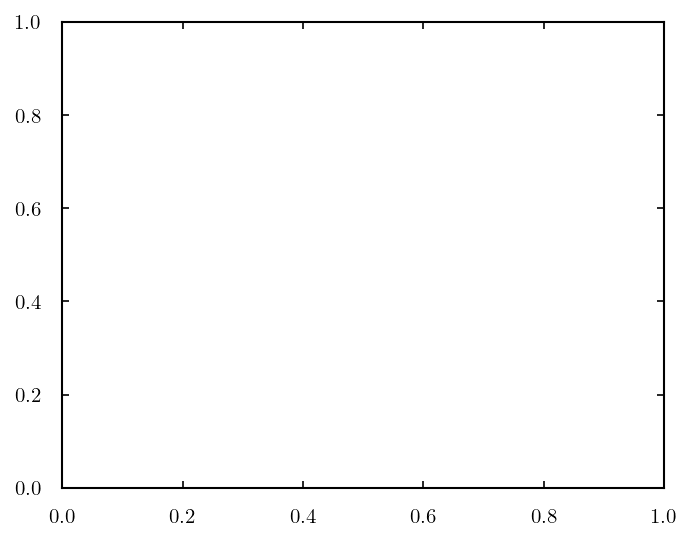

In [ ]:
# plot the profile for this ice sheet
fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.5), dpi=150, constrained_layout=True)
ax.plot(profile_V['depth'], profile_V['pressure'], c='red', lw=1.5, alpha=0.99, label='Pressure (MPa)')
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Pressure (MPa)', color='red')
ax.set_ylim(0, max(profile_V['pressure']))
ax2 = ax.twinx()
ax2.plot(profile_V['depth'], profile_V['temperature'], c='blue', lw=1.5, alpha=0.99, label='Temperature (K)')
ax2.set_ylabel('Temperature (K)', color='blue')
ax2.set_ylim(min(profile_V['temperature']), max(profile_V['temperature']))
ax.set_xlim(min(profile_V['depth']), max(profile_V['depth']))

In [ ]:
test_H_km = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 
             16, 17, 18, 19, 20, 22, 24, 26, 28, 30, 35, 40, 45, 
             50, 75, 100]

results_phases = []

for H_km in test_H_km:
    H = H_km * 1000
    #F, T_c, regime, phase_info = compute_required_heat_flux_with_phases_IV(H, T_H=273, T_0=1)
    F, T_c, regime, phase_info = compute_required_heat_flux_with_phases_V(H, T_H=273, gas_layer=False)
    
    results_phases.append({
        'H_km': H_km,
        'Flux': F,
        'T_c': T_c,
        'regime': regime,
        'phase': phase_info['phase_base'],
        'Ra': phase_info['Ra'],
        'H_lid': phase_info.get('H_lid', 0),
        'H_conv': phase_info.get('H_conv', 0)
    })
    
    print(f"{H_km:7.0f} {phase_info['phase_base']:>6s} {F:11.6f} {phase_info['Ra']:14.6e} {regime:>12s}")

dict_keys(['depth', 'pressure', 'conductive temperature', 'density', 'phase', 'k', 'alpha', 'eta'])
11


IndexError: list index out of range

Text(0, 0.5, 'Required Heat Flux F (W/m²)')

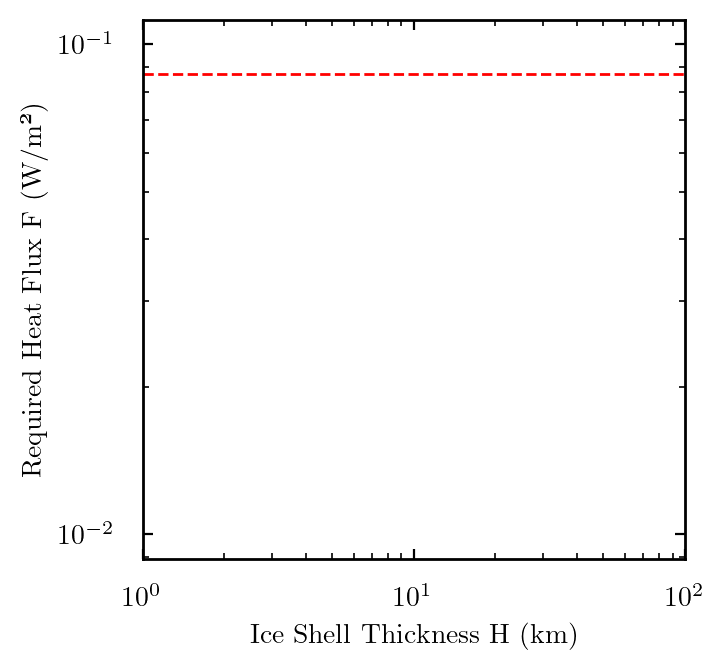

In [ ]:
# plot heat flux vs ice shell thickness for the range of test_H_km using the results_phases data
H_km_values = [res['H_km'] for res in results_phases]
F_values = [res['Flux'] for res in results_phases]

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=200)

ax.loglog(H_km_values, F_values, 'o-', color='black', lw=1, markersize=2)

# plot a horizontal line at F=0.087 W/m² to indicate current earth heat flux
ax.axhline(y=0.087, color='red', linestyle='--', lw=1, label='Modern Earth Surface Heat Flux')

ax.set_xlim(1, 100)
#ax.set_ylim(0.0005, 0.2)

#ax.legend(loc='upper right', fontsize=8)

ax.set_xlabel('Ice Shell Thickness H (km)')
ax.set_ylabel('Required Heat Flux F (W/m²)')


In [ ]:
# for each entry in the results_phases, plot the plots

for res in results_phases:
    H_km = res['H_km']
    F = res['Flux']
    T_c = res['T_c']
    regime = res['regime']
    phase = res['phase']
    Ra = res['Ra']
    H_lid = res.get('H_lid', 0)
    H_conv = res.get('H_conv', 0)
    
    print(f"H: {H_km} km, F: {F:.6f} W/m², T_c: {T_c:.2f} K, Regime: {regime}, Phase: {phase}, Ra: {Ra:.6e}, H_lid: {H_lid:.1f} m, H_conv: {H_conv:.1f} m")
    
    #plot_phase_vs_depth(H=H_km*1000, T_H=260, T_0=220)
    #plot_temperature_vs_depth(H=H_km*1000, T_H=260, T_0=220)
    #plot_viscosity_vs_depth(H=H_km*1000, T_H=260, T_0=220)
    #plot_Ra_vs_depth(H=H_km*1000, T_H=260, T_0=220)
    #plot_heat_flux_vs_depth(H=H_km*1000, T_H=260, T_0=220)
    #plot_convection_vs_lid(H=H_km*1000, T_H=260, T_0=220)

In [ ]:
# what is the pressure at the bottom of the ice shell for each thickness in test_H_km?
print("\nPressure at the bottom of the ice shell for each thickness:")
for res in results_phases:
    H_km = res['H_km']
    H_m = H_km * 1000
    props = ice_profile(H_m, T_H=273, T_0=35)
    rho = props['density'][-1]
    G = 6.67430e-11  # gravitational constant
    M = 5.972e24     # mass of Earth (kg)
    R = 6.371e6      # radius of Earth (m)
    g = G * M / R**2  # gravitational acceleration at the surface
    P_MPa = rho * g * H_m / 1e6
    print(f"H: {H_km} km, Phase: {props['phase'][-1]}, Pressure: {P_MPa:.2f} MPa")


Pressure at the bottom of the ice shell for each thickness:
H: 1 km, Phase: Ih, Pressure: 9.00 MPa
H: 2 km, Phase: Ih, Pressure: 18.01 MPa
H: 3 km, Phase: Ih, Pressure: 27.01 MPa
H: 4 km, Phase: Ih, Pressure: 36.02 MPa
H: 5 km, Phase: Ih, Pressure: 45.02 MPa
H: 6 km, Phase: Ih, Pressure: 54.03 MPa
H: 7 km, Phase: Ih, Pressure: 63.03 MPa
H: 8 km, Phase: Ih, Pressure: 72.04 MPa
H: 9 km, Phase: Ih, Pressure: 81.04 MPa
H: 10 km, Phase: Ih, Pressure: 90.05 MPa
H: 11 km, Phase: Ih, Pressure: 99.05 MPa
H: 12 km, Phase: Ih, Pressure: 108.06 MPa
H: 13 km, Phase: Ih, Pressure: 117.06 MPa
H: 14 km, Phase: Ih, Pressure: 126.07 MPa
H: 15 km, Phase: Ih, Pressure: 135.07 MPa
H: 16 km, Phase: Ih, Pressure: 144.08 MPa
H: 17 km, Phase: Ih, Pressure: 153.08 MPa
H: 18 km, Phase: Ih, Pressure: 162.09 MPa
H: 19 km, Phase: Ih, Pressure: 171.09 MPa
H: 20 km, Phase: Ih, Pressure: 180.10 MPa
H: 22 km, Phase: Ih, Pressure: 198.11 MPa
H: 24 km, Phase: III, Pressure: 273.39 MPa
H: 26 km, Phase: III, Pressure: 296